In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from resources.lattices import connectivity

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch_geometric.nn import GCNConv, GATConv, global_mean_pool, global_add_pool
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.utils import to_networkx
from torchinfo import summary

import optuna 
import networkx as nx

from resources.MLdata import *
from resources.MLfunc import *
from resources.MLmodels import GCN, GAT

# GNN Stress-Strain Curve Optimization
General approximation from change in node coordinate components to change in stress-strain curve.

In [3]:
DAT = DATA(load=True, model="GNN")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")     

Using device: cpu


In [4]:
DAT.train_in.shape, DAT.train_out.shape

((3588, 357, 2), (3588, 201))

In [5]:
perIN_ = DAT.perIN.reshape(int(len(DAT.perIN)/2), 2)
perIN_ = np.array([i for i in perIN_ if max(perIN_[:,0]) != i[0] and min(perIN_[:,0]) != i[0] and 
                                        max(perIN_[:,1]) != i[1] and min(perIN_[:,1]) != i[1]])
elems = connectivity("FCC", perIN_/1000, [10/1000]*20)

edges = elems[:, 1:] - 1
edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

In [6]:
in_size = DAT.train_in.shape[-1]
out_size = DAT.train_out.shape[-1]
h_size = [8, 32, 128]

BATCH_SIZE = 16
LEARNING_RATE = 1e-3
n_epochs = 5000

In [7]:
trainDS = [Data(x=torch.tensor(i, dtype=torch.float), edge_index=edge_index, y=torch.tensor(j, dtype=torch.float)) for i,j in zip(DAT.train_in[:1000], DAT.train_outST[:1000])]
valDS = [Data(x=torch.tensor(i, dtype=torch.float), edge_index=edge_index, y=torch.tensor(j, dtype=torch.float)) for i,j in zip(DAT.val_in, DAT.val_outST)]
testDS = [Data(x=torch.tensor(i, dtype=torch.float), edge_index=edge_index, y=torch.tensor(j, dtype=torch.float)) for i,j in zip(DAT.test_in, DAT.test_outST)]

train_dataloader = DataLoader(dataset=trainDS, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(dataset=valDS, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(dataset=testDS, batch_size=BATCH_SIZE, shuffle=False)

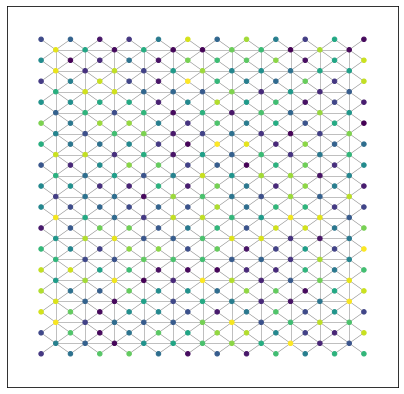

In [8]:
visualize_graphNetwork(train_dataloader, pos=perIN_, colors=None, layout="kk")

In [19]:
gcn1 = GCN(in_size, h_size, out_size, norm="batch", pool="mean").to(device)
gat1 = GAT(in_size, h_size, out_size, heads=2, norm="batch", pool="mean").to(device)
model = gat1

opt = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
lossf = nn.MSELoss()

earlyStop = EarlyStopping(patience=25, min_delta=1e-8, verbose=True)

ReduceLR = optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.7, patience=8, threshold=1e-3, verbose=True)
OneCycleLR = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=1e-3, steps_per_epoch=len(train_dataloader), epochs=n_epochs)
CosineAnnealingLR = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)

In [20]:
gat1, epoch, train_lossLog, val_lossLog = train_model('gnn', model, lossf, n_epochs, opt, train_dataloader, 
                                                      val_dataloader=val_dataloader, scheduler=ReduceLR, 
                                                      earlyStop=earlyStop, verbose=10)

Epoch: 1 - Loss: 0.23395158350467682
Epoch: 10 - Loss: 0.00868387520313263
Epoch: 20 - Loss: 0.008506004698574543
Epoch: 30 - Loss: 0.00347866490483284
Epoch: 40 - Loss: 0.003976576030254364
Epoch: 50 - Loss: 0.004529942758381367
Epoch: 60 - Loss: 0.0030248253606259823
Epoch: 70 - Loss: 0.005099672824144363
Epoch: 80 - Loss: 0.00726515194401145
Epoch: 90 - Loss: 0.003248369786888361
Epoch: 100 - Loss: 0.00557652348652482
Epoch: 110 - Loss: 0.004610761068761349
Epoch: 120 - Loss: 0.0033868825994431973
Epoch 00129: reducing learning rate of group 0 to 2.8000e-05.
Epoch: 130 - Loss: 0.004129065666347742
Epoch: 140 - Loss: 0.005036013666540384
Epoch 00143: reducing learning rate of group 0 to 1.9600e-05.
Epoch: 150 - Loss: 0.004051067866384983
Epoch 00152: reducing learning rate of group 0 to 1.3720e-05.
Epoch: 160 - Loss: 0.0039006778970360756
Epoch 00161: reducing learning rate of group 0 to 9.6040e-06.
Early stopping triggered after 25 epochs without improvement.
Best Epoch: 58, with lo

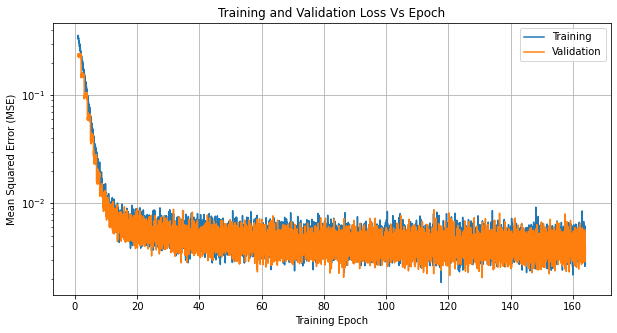

In [21]:
plot_loss(epoch, train_lossLog, val_lossLog)

In [22]:
test_outputs = predict_model("gnn", model, test_dataloader)
test_outputs = standardize(test_outputs, DAT.outParams[0], DAT.outParams[1], mode=1)

In [25]:
err = list(sum(abs(DAT.test_out - test_outputs)))
err.index(min(err)), err.index(max(err))

(29, 91)

In [1]:
plot_StressStrainOUT(DAT.perOUT, DAT.train_out, test_outputs, indx=91)

NameError: name 'plot_StressStrainOUT' is not defined